In [454]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from math import ceil
from joblib import Parallel, delayed
from matplotlib.gridspec import GridSpec

# Czytanie danych

In [455]:
data_path = '../input/breast-cancer-wisconsin-data/data.csv'
data = pd.read_csv(data_path)

In [456]:
data['benign'] = (data.diagnosis == 'M').astype(int)
data.drop(['id', 'diagnosis','Unnamed: 32'], axis=1, inplace=True)
data.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,benign
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [457]:
X_train, X_test, y_train, y_test = train_test_split(
    data, data['benign'], test_size = 0.2, random_state = 1234, stratify = data['benign'])
X_train.drop(['benign'], axis=1, inplace=True)

# Trenowanie modelu

In [458]:
model = RandomForestClassifier(n_estimators = 50, random_state = 1234)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, random_state=1234)

# Klasa PDP

In [459]:
class PDP:

    def fit(self, data, feature, model):
        
        classes = model.classes_.size
        predict = model.predict_proba
        target = data[feature]
        feature_grid = np.unique(np.percentile(target, np.linspace(0, 100, 50)))
        batch_size = ceil(data.shape[0] / feature_grid.size)
        
        parallel = Parallel()
        outputs = parallel(delayed(_predict)(batch,feature_grid,feature,classes,predict)
                           for batch in _data_iter(data, batch_size))
 
        results = []
        for output in zip(*outputs):
            result = pd.concat(output, ignore_index = True)
            result.columns = feature_grid
            results.append(result)

        self.results_ = results
        self.feature_ = feature
        return self

    def plot(self, target_class = 0):
        figure = GridSpec(5, 1)
        ax = plt.subplot(figure[1:, :])

        results = self.results_[target_class]
        x = results.columns

        pd = results.values.mean(axis = 0)
        pd -= pd[0]

        pd_std = results.values.std(axis = 0)
        upper = pd + pd_std
        lower = pd - pd_std
        
        ax.set_title('PDP dla: {}'.format(self.feature_))
        ax.plot(
            x, pd,marker = 'o', markersize = 4)
        ax.plot(
            x, [0] * pd.size,
            linestyle = '--', linewidth = 1.5)
        ax.fill_between(x, upper, lower, alpha = 0.0)
        ax.set_xlabel(self.feature_, fontsize = 10)


        ax.set_facecolor('white')
        ax.get_yaxis().tick_left()
        ax.get_xaxis().tick_bottom()
        for direction in ('top', 'left', 'right', 'bottom'):
            ax.spines[direction].set_visible(False)

        for axis in ('x', 'y'):
            ax.grid(True, 'major', axis, ls = '--', lw = .5, c = 'k', alpha = .3)

        return figure
    
def _data_iter(data, batch_size):
    n_rows = data.shape[0]
    for i in range(0, n_rows, batch_size):
        yield data[i:i + batch_size].reset_index(drop = True)


def _predict(batch, feature_grid, feature, classes, predict):
    index_batch = np.repeat(batch.index.values, repeats = feature_grid.size)
    ice_data = batch.iloc[index_batch].copy()
    ice_data[feature] = np.tile(feature_grid, batch.shape[0])

    results = []
    prediction = predict(ice_data)
    for nclass in range(classes):
        
        result = prediction[:, nclass]
        reshaped = result.reshape((batch.shape[0], feature_grid.size))
        result = pd.DataFrame(reshaped)
        results.append(result)

    return results

# Wykresy PDP dla różnych współczynników

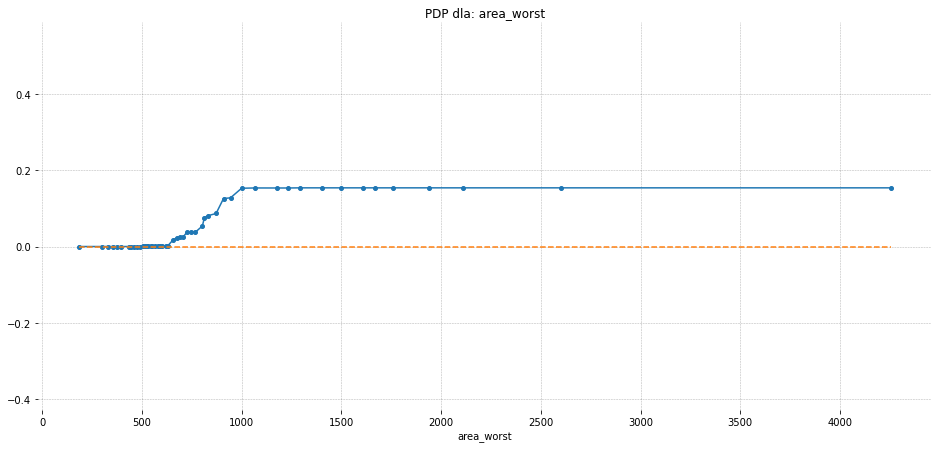

In [460]:
pdp = PDP()
pdp.fit(X_train, feature = 'area_worst', model = model)
pdp.plot(target_class = 1)
plt.show()

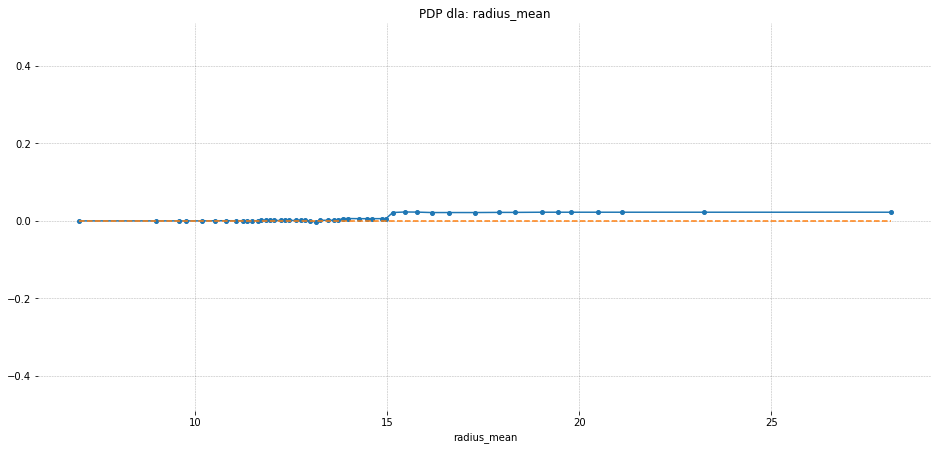

In [461]:
pdp.fit(X_train, feature = 'radius_mean', model = model)
pdp.plot(target_class = 1)
plt.show()

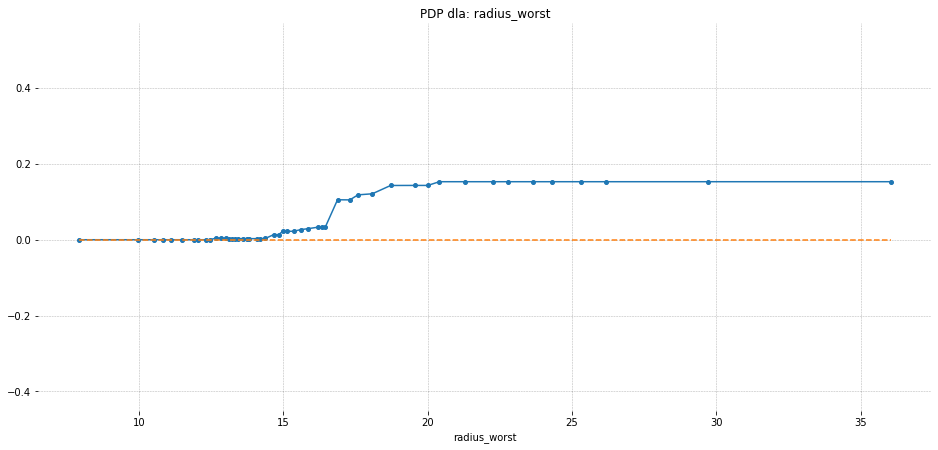

In [462]:
pdp.fit(X_train, feature = 'radius_worst', model = model)
pdp.plot(target_class = 1)
plt.show()

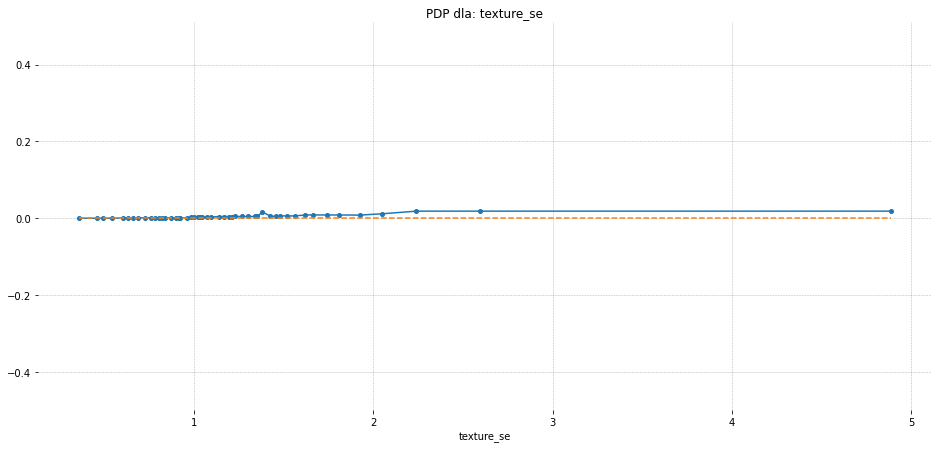

In [463]:
pdp.fit(X_train, feature = 'texture_se', model = model)
pdp.plot(target_class = 1)
plt.show()